In [32]:
import optuna
from collections.abc import Callable, Iterable, Sequence
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import pickle

optuna.logging.set_verbosity(optuna.logging.ERROR)
orig_settings = np.seterr(all='raise', over='ignore', under='ignore')


SAVE_FILENAME = 'analitic_results.csv'

In [2]:
class Polynomial:
    def __init__(self, *coefs: float, max_x=10, eps=1e-10):
        self.eps = eps
        self.max_x = max_x
        if isinstance(coefs[0], Polynomial):
            self._coefs = coefs[0]._coefs
            self.normalize()
        else:
            self._coefs = np.array([0.], dtype=np.longdouble)
            self.coefs = coefs
            self.normalize()
    def normalize(self, eps = None):
        if eps is None:
            eps = self.eps
        x = 1
        for i, coef in enumerate(self.coefs):
            # print(coef, x, eps)
            if coef * x <= eps:
                self.coefs[i] = 0
            x *= self.max_x
        k = len(self.coefs)
        for coef in reversed(self.coefs):
            if coef != 0:
                break
            k -= 1
        if k == 0:
            k = 1
        self._coefs = self._coefs[:k]

    @property
    def coefs(self):
        return self._coefs
    @coefs.setter
    def coefs(self, value):
        if isinstance(value, (list, tuple)):
            self._coefs = np.asarray(value)
        else:
            raise TypeError
    def __setitem__(self, key, value):
        if isinstance(key, int) or isinstance(key, slice):
            self._coefs[key] = value
        else:
            raise TypeError
    def __getitem__(self, key):
        if isinstance(key, int) or isinstance(key, slice):
            return self._coefs[key]
        else:
            raise TypeError
    def __call__(self, x):
        result = self._coefs[0]
        cur_x = x
        for coef in self._coefs[1:]:
            result += cur_x * coef
            cur_x *= x
        return result
    def __len__(self):
        return len(self._coefs)
    def __repr__(self):
        res = '0'
        if self._coefs[0] != 0:
            res = f'{self._coefs[0]}'
        if len(self._coefs) > 1 and self._coefs[1] != 0:
            res += f'+{self._coefs[1]}x'
        for i, coef in enumerate(self._coefs[2:]):
            if coef != 0:
                res += f"+{coef}x^{i+2}"
        return res
    def __iadd__(self, other):
        if isinstance(other, Polynomial):
            delta = len(other) - len(self)
            if delta > 0:
                self._coefs = np.concatenate([self._coefs, np.zeros(delta)], axis=None)
            self._coefs[:len(other)] += other._coefs
            self.normalize()
            return self
        elif isinstance(other, int | float):
            self._coefs[0] += other
            return self
        else:
            raise TypeError
    def __imul__(self, other):
        if isinstance(other, Polynomial):
            new_len = len(other) + len(self) - 1
            ans = np.zeros(new_len)
            for i, coef in enumerate(other._coefs):
                ans[i:i+len(self)] += coef * self._coefs
            self._coefs = ans
            self.normalize()
            return self
        elif isinstance(other, (int, float)):
            self._coefs *= other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __mul__(self, other):
        ans = Polynomial(*self.coefs, max_x=self.max_x, eps=self.eps)
        ans *= other
        return ans
    def __idiv__(self, other):
        if isinstance(other, (int, float)):
            self._coefs /= other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __ipow__(self, other):
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([1])
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self **= other // 2
                self *= self
            else:
                remember = Polynomial(*self._coefs.copy(), max_x=self.max_x, eps=self.eps)
                self **= other // 2
                self *= self
                self *= remember
            return self
        else:
            raise TypeError
    def composition(self, other):
        if isinstance(other, Polynomial):
            result = Polynomial(self._coefs[0], max_x=self.max_x, eps=self.eps)
            cur_x = other
            for coef in self._coefs[1:]:
                result += cur_x * coef
                cur_x *= other
            return result
        else:
            raise TypeError
    def __ilshift__(self, other):
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([0, 1])
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self <<= other // 2
                self = self.composition(self)
            else:
                remember = Polynomial(*self._coefs.copy(), max_x=self.max_x, eps=self.eps)
                self <<= other // 2
                self = self.composition(self)
                self = self.composition(remember)
            return self
        else:
            raise TypeError
    def integrate(self):
        new_coef = self.coefs / (np.arange(len(self.coefs)) + 1)
        new_coef = np.concatenate([np.zeros(1), new_coef])
        return Polynomial(*new_coef, max_x=self.max_x, eps=self.eps)


In [3]:
class PolynomialCoefsMod2:
    def __init__(self, *coefs: float, max_x=1., eps=1e-10, offset = 0, verbose=False):
        self.eps = eps
        self.max_x = max_x
        self.max_sqr_x = max_x * max_x
        self.offset = offset
        self.verbose = verbose
        if isinstance(coefs[0], PolynomialCoefsMod2):
            self._coefs = coefs[0]._coefs
        else:
            self._coefs = np.array([0.], dtype=np.longdouble)
            self.coefs = coefs
        self.normalize()
    def tell(self, s: str):
        if self.verbose:
            print(s)
    def is_pos_infty(self):
        return (self._coefs == float('+inf')).any()
    def is_neg_infty(self):
        return (self._coefs == float('-inf')).any()
    def to_pos_infty(self):
        self._coefs = np.array([float('inf')])
        self.offset %= 2
    def to_neg_infty(self):
        self._coefs = np.array([float('-inf')])
        self.offset %= 2
    def normalize(self, eps: float | None = None):
        self.tell('normalize')
        if self.is_pos_infty():
            self.to_pos_infty()
            return
        if self.is_neg_infty():
            self.to_neg_infty()
            return
        if eps is None:
            eps = self.eps
        x = 1
        for i, coef in enumerate(self.coefs):
            try:
                if abs(coef * x) <= abs(eps):
                    self.coefs[i] = 0
            except OverflowError as e:
                print(f"coef = {coef}")
                print(f"x = {x}")
                print(e)
                raise e
            except FloatingPointError as e:
                print(f"coef = {coef}")
                print(f"x = {x}")
                print(e)
                raise e
            x *= self.max_sqr_x
        k_begin = 0
        for coef in self.coefs:
            if coef != 0:
                break
            k_begin += 1
        if k_begin == len(self.coefs):
            k_begin = len(self.coefs)-1
        self.offset += k_begin*2
        self._coefs = self._coefs[k_begin:]
        k_end = len(self.coefs)
        for coef in reversed(self.coefs):
            if coef != 0:
                break
            k_end -= 1
        if k_end == 0:
            k_end = 1
        self._coefs = self._coefs[:k_end]
    def copy(self):
        self.tell('copy')
        return PolynomialCoefsMod2(*self.coefs.copy(),
                                  max_x=self.max_x,
                                  eps=self.eps,
                                  offset=self.offset,
                                  verbose=self.verbose,
        )
    @property
    def coefs(self):
        return self._coefs
    @coefs.setter
    def coefs(self, value):
        if isinstance(value, (list, tuple)):
            self._coefs = np.asarray(value)
        else:
            raise TypeError
    def __setitem__(self, key: int | slice, value):
        self.tell('__setitem__')
        if isinstance(key, int):
            if key < self.offset:
                raise IndexError
            key -= self.offset
            if key >= len(self._coefs):
                raise IndexError
            if key % 2 != 0:
                raise IndexError
            self._coefs[key] = value
        elif isinstance(key, slice):
            self._coefs[key] = value
        else:
            raise TypeError
    def __getitem__(self, key):
        self.tell('__getitem__')
        if isinstance(key, int):
            if key < self.offset:
                return 0
            key -= self.offset
            if key >= len(self._coefs):
                return 0
            if key % 2 != 0:
                return 0
            key //= 2
            return self._coefs[key]
        elif isinstance(key, slice):
            return self._coefs[key]
        else:
            raise TypeError
    def __call__(self, x):
        self.tell('__call__')
        if self.is_pos_infty():
            return float('+inf')
        if self.is_neg_infty():
            return float('-inf')
        try:
            cur_x = x ** self.offset
            result = self._coefs[0] * cur_x
            x_sqr = x * x
            for coef in self._coefs[1:]:
                cur_x *= x_sqr
                result += cur_x * coef
            return result
        except Exception as e:
            print(e)
            return float('+inf')
    def __len__(self):
        return len(self._coefs)
    def __repr__(self):
        res = '0'
        if (self.offset == 0) and (self._coefs[0] != 0):
            res = f'{self._coefs[0]}'
        elif (self.offset == 1) and (self._coefs[0] != 0):
            res = f'{self._coefs[0]}x'
        else:
            res = f"{self._coefs[0]}x^{self.offset}"
        for i, coef in enumerate(self._coefs[1:]):
            if coef != 0:
                res += f"+{coef}x^{2*(i+1)+self.offset}"
        return res
    def __iadd__(self, other):
        self.tell('__iadd__')
        if isinstance(other, PolynomialCoefsMod2):
            if self.offset % 2 != other.offset % 2:
                raise TypeError(f"Это полиномы разной чётности!\n\tp1={self}\n\tp2={other}")
            self_min = self.offset
            self_max = self.offset + len(self._coefs) * 2
            other_min = other.offset
            other_max = other.offset + len(other._coefs) * 2
            bias = min(self_min, other_min)
            self_min -= bias
            self_max -= bias
            other_min -= bias
            other_max -= bias
            self_min //= 2
            self_max //= 2
            other_min //= 2
            other_max //= 2
            new_coefs = np.zeros(max(self_max, other_max))
            new_coefs[self_min : self_max] += self._coefs
            new_coefs[other_min : other_max] += other._coefs
            self._coefs = new_coefs
            self.offset = bias
            return self
        elif isinstance(other, int | float):
            self._coefs[0] += other
            return self
        else:
            raise TypeError
    def __add__(self, other):
        self.tell('__add__')
        res = self.copy()
        res += other
        return res
    def __imul__(self, other):
        self.tell('__imul__')
        if isinstance(other, PolynomialCoefsMod2):
            self.offset += other.offset
            new_len = len(other) + len(self) - 1
            ans = np.zeros(new_len)
            for i, coef in enumerate(other._coefs):
                try:
                    ans[i:i+len(self)] += coef * self._coefs
                except FloatingPointError as e:
                    print(e)
                    print(f"coef={coef}")
                    print(f"self._coefs={self._coefs}")
                    self.to_pos_infty()
                    break
                    raise e
            else:
                self._coefs = ans
                self.normalize()
            return self
        elif isinstance(other, (int, float)):
            self._coefs = self._coefs * other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __mul__(self, other):
        self.tell('__mul__')
        ans = self.copy()
        ans *= other
        return ans
    def __idiv__(self, other):
        self.tell('__idiv__')
        if isinstance(other, (int, float)):
            self._coefs /= other
            return self
        else:
            raise TypeError(f"other={other} has type {type(other)}")
    def __ipow__(self, other):
        self.tell('__ipow__')
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([1])
                self.offset = 0
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self **= other // 2
                self *= self
            else:
                remember = self.copy()
                self **= other // 2
                self *= self
                self *= remember
            return self
        else:
            raise TypeError
    def __pow__(self, other):
        self.tell('__pow__')
        res = self.copy()
        res **= other
        return res
    def composition(self, other):
        self.tell('composition')
        if isinstance(other, PolynomialCoefsMod2):
            cur_x = other ** self.offset
            result = cur_x * self._coefs[0]
            other_sqr = other.copy()
            other_sqr **= 2
            for coef in self._coefs[1:]:
                cur_x *= other_sqr
                result += cur_x * coef
            result.normalize()
            return result
        else:
            raise TypeError
    def __ilshift__(self, other):
        if isinstance(other, int):
            if other == 0:
                self._coefs = np.array([0, 1])
                return self
            if other == 1:
                return self
            if other % 2 == 0:
                self <<= other // 2
                self = self.composition(self)
            else:
                remember = self.copy()
                self <<= other // 2
                self = self.composition(self)
                self = remember.composition(self)
            self.normalize()
            return self
        else:
            raise TypeError()
    def self_integrate(self):
        self._coefs /= 2 * np.arange(len(self._coefs)) + 1 + self.offset
        self.offset += 1
        return self
    def integrate(self):
        ret = self.copy()
        ret.self_integrate()
        return ret
    def l2_metric_with_1(self, l: float = 1):
        I1 = l
        I2 = self.integrate()(l)
        tmp = self.copy()
        tmp **= 2
        I3 = tmp.integrate()(l)
        return (I1 - 2 * I2 + I3) ** 0.5


## Tests

In [4]:
a = Polynomial(1.,1,0.0)
a

1.0+1.0x

In [5]:
a = PolynomialCoefsMod2(1.,1,)
a

1.0+1.0x^2

In [6]:
a = Polynomial(1.,1,0.0)
a <<= 4
a

4.0+1.0x

In [7]:
a = PolynomialCoefsMod2(1.,1,)
print("a =", a)
b = PolynomialCoefsMod2(1.,1, 1e-10)
print("b =", b)
b + a

a = 1.0+1.0x^2
b = 1.0+1.0x^2


2.0+2.0x^2

In [8]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
a **= 2
a

a = 1.0x^2


1.0x^4

In [9]:
a = PolynomialCoefsMod2(0.,0,0,1,1)
print("a =", a)
b = PolynomialCoefsMod2(0.,1,1, 1e-100)
print("b =", b)
a *= b
a

a = 1.0x^6+1.0x^8
b = 1.0x^2+1.0x^4


1.0x^8+2.0x^10+1.0x^12

In [10]:
a = PolynomialCoefsMod2(0.,1,1)
a **= 0
a

1

In [11]:
a = PolynomialCoefsMod2(1.)
print("a =", a)
b = PolynomialCoefsMod2(0.,0,1, verbose=True)
print("b =", b)
a + b

a = 1.0
normalize
b = 1.0x^4


1.0+1.0x^4

In [12]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
b = PolynomialCoefsMod2(1.,1)
print("b =", b)
p = b.composition(a)
p

a = 1.0x^2
b = 1.0+1.0x^2


1.0+1.0x^4

In [13]:
a = PolynomialCoefsMod2(
    0.12406847980011189,
    0.08388543203301584,
    0.2725473901443718,
    0.30025416528032345,
    0.1866604629392209,
    0.1446454363858829,
    0.10335132683430093,
    0.03811217352447022,
    0.0056773854827695805,
    verbose=True
)
a.composition(a)
a

normalize
composition
__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


0.12406847980011189+0.08388543203301584x^2+0.2725473901443718x^4+0.30025416528032345x^6+0.1866604629392209x^8+0.1446454363858829x^10+0.10335132683430093x^12+0.03811217352447022x^14+0.0056773854827695805x^16

In [14]:
a = PolynomialCoefsMod2(0.,1)
print("a =", a)
a <<= 5
a

a = 1.0x^2


1.0x^32

In [15]:
a = PolynomialCoefsMod2(1.,1)
a

1.0+1.0x^2

In [16]:
a = PolynomialCoefsMod2(26.0,80.0,144,168,138,80,32,8, 1, verbose=True)
a.composition(a)

normalize
composition
__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


4.412788774590618e+22+2.1692361890508387e+24x^2+5.389482125372266e+25x^4+9.014081419635577e+26x^6+1.1407265517962137e+28x^8+1.1641148019383992e+29x^10+9.971649212031729e+29x^12+7.369402808440385e+30x^14+4.793732775501987e+31x^16+2.78662999143558e+32x^18+1.4649079250425876e+33x^20+7.030951771907446e+33x^22+3.105211283628861e+34x^24+1.2702128930885274e+35x^26+4.8391280101263574e+35x^28+1.725097073874842e+36x^30+5.778139908830491e+36x^32+1.8248866802137345e+37x^34+5.45148491248255e+37x^36+1.54463502815012e+38x^38+4.161386004275297e+38x^40+1.0683352208525335e+39x^42+2.6187513743569273e+39x^44+6.140084983292086e+39x^46+1.379276604943761e+40x^48+2.972795238749786e+40x^50+6.156003958828599e+40x^52+1.2262724030264044e+41x^54+2.3524414993148458e+41x^56+4.350554211932464e+41x^58+7.763878393871583e+41x^60+1.3381466238703277e+42x^62+2.2293227362188736e+42x^64+3.592638352060397e+42x^66+5.604390253497382e+42x^68+8.468344872913988e+42x^70+1.2401801882612322e+43x^72+1.7612836738846842e+43x^74+2.426929

In [17]:
b.composition(a)


__pow__
copy
normalize
__ipow__
__mul__
copy
normalize
__imul__
copy
normalize
__ipow__
__ipow__
__imul__
normalize
__imul__
normalize
__mul__
copy
normalize
__imul__
__iadd__
normalize


677.0+4160.0x^2+13888.0x^4+31776.0x^6+54792.0x^8+74624.0x^10+82432.0x^12+74944.0x^14+56472.0x^16+35296.0x^18+18208.0x^20+7664.0x^22+2580.0x^24+672.0x^26+128.0x^28+16.0x^30+1.0x^32

In [18]:
b = PolynomialCoefsMod2(1., 1, eps=1e-100)
b <<= 7
b

210066388901.0+5163215782400.0x^2+64827181969920.0x^4+552146121580800.0x^6+3577447266529344.0x^8+1.8758502169639936e+16x^10+8.273466075459174e+16x^12+3.1509101193418086e+17x^14+1.0559870761388552e+18x^16+3.1588761203658875e+18x^18+8.528109500247939e+18x^20+2.096203102647606e+19x^22+4.7246343451889345e+19x^24+9.822144040450553e+19x^26+1.892668070245958e+20x^28+3.3944188899198154e+20x^30+5.685947594416971e+20x^32+8.922569409653853e+20x^34+1.3150637638180258e+21x^36+1.8244814152603615e+21x^38+2.3872745796037766e+21x^40+2.950915559146382e+21x^42+3.450841157549203e+21x^44+3.8224518865816026e+21x^46+4.0148128893170614e+21x^48+4.0020463555213305e+21x^50+3.788924330963182e+21x^52+3.409035231099645e+21x^54+2.916344324841102e+21x^56+2.372992368997508e+21x^58+1.837018423688074e+21x^60+1.35317008898861e+21x^62+9.484815981449223e+20x^64+6.325770978549904e+20x^66+4.0135710970351164e+20x^68+2.4219230084704122e+20x^70+1.3894198911291508e+20x^72+7.574148396048163e+19x^74+3.92097150891867e+19x^76+1.9261

```Sqrt[Integrate[Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[\(40)1 + Power[x,2]\(41),2]\(41),2]\(41),2]\(41),2]\(41),2]\(41),2]-1\(41),2],{x,0,1}]]```

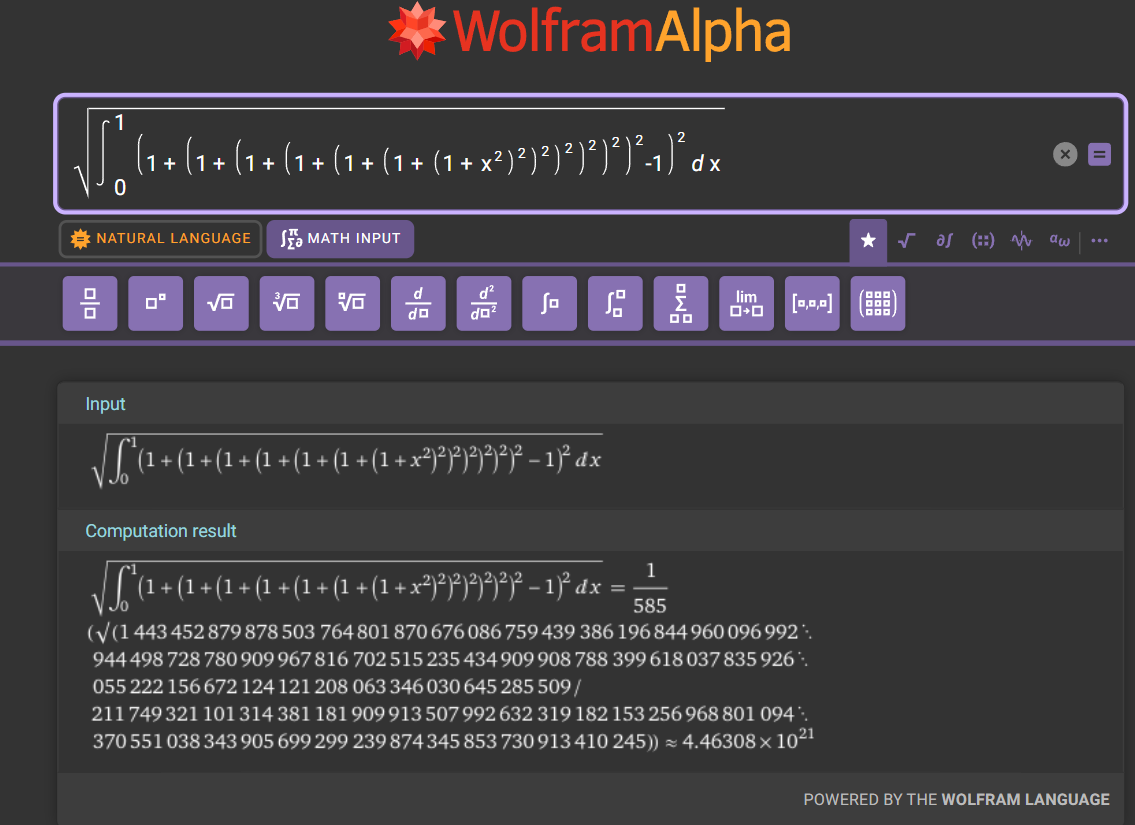

In [19]:
b.l2_metric_with_1()

4.463077479281998e+21

## Body

In [20]:
def create_pol_by_odd_coefs(odd_coefs: Iterable[float]):
    return PolynomialCoefsMod2(*odd_coefs, max_x=1, offset=1)

In [21]:
def pol(odd_coefs: Iterable[float | int]):
    p = create_pol_by_odd_coefs(odd_coefs)
    return p

In [22]:
a = pol([1.00,1.00,0])
a

1.0x+1.0x^3

In [23]:
a <<= 2
a

1.0x+2.0x^3+3.0x^5+3.0x^7+1.0x^9

In [24]:
a <<= 2
a

1.0x+4.0x^3+18.0x^5+78.0x^7+315.0x^9+1182.0x^11+4107.0x^13+13215.0x^15+39375.0x^17+108768.0x^19+279168.0x^21+667440.0x^23+1489788.0x^25+3109888.0x^27+6077460.0x^29+11122452.0x^31+19056411.0x^33+30540060.0x^35+45723258.0x^37+63851670.0x^39+83027583.0x^41+100339254.0x^43+112469499.0x^45+116666343.0x^47+111716316.0x^49+98469000.0x^51+79621704.0x^53+58826280.0x^55+39520584.0x^57+24001704.0x^59+13083192.0x^61+6344568.0x^63+2707353.0x^65+1002708.0x^67+316746.0x^69+83430.0x^71+17775.0x^73+2934.0x^75+351.0x^77+27.0x^79+1.0x^81

In [25]:
def sign_l2_loss(f: PolynomialCoefsMod2, interval:list[float]=[0,1]):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right
    try:
        assert left == 0
        return f.l2_metric_with_1(right)
    except OverflowError:
        return float('+inf')
    

In [26]:
def sign_max_loss(f: Callable, interval=[0,1], h=1e-5):
    assert len(interval) == 2, "Интервал это 2 числа."
    left, right = interval
    assert left < right    
    n_steps = int((right - left) / h)
    assert n_steps != 0, "Слишком маленький интервал по сравнению с шагом"
    try:
        x = left
        ans = abs(f(x))
        for _ in range(1, n_steps):
            x += h
            delta = abs(f(x)-1)
            if math.isnan(delta):
                return float('+inf')
            ans = max(ans, delta)
        return ans
    except OverflowError:
        return float('+inf')

In [27]:
def repeat(f: PolynomialCoefsMod2, n: int):
    f <<= n
    return f

In [28]:
def NewtonS(odd_coefs: list, n: int):
    f = pol(odd_coefs)
    f = repeat(f, n)
    return f

In [29]:
def abstruct_objective(coef_len: int, max_x: float, n: int, metric='l2'):
    def objective(trial: optuna.Trial):
        odd_coefs = []
        for i in range(coef_len):
            odd_coefs.append(
                trial.suggest_float(f"a{i}", -10, 10)
            )
        f = NewtonS(odd_coefs, n)
        loss = float('+inf')
        if metric == 'l2':
            loss = sign_l2_loss(f, [0, max_x])
        elif metric == 'max':
            loss = sign_max_loss(f, [0, max_x], max_x / 5e3)
        return loss
    return objective

In [30]:
def experiment(coef_len: int, max_x: float, n: int, metric='l2', n_trials=100):
    filename = f"sqlite:///sampler_{coef_len}_{int(max_x)}_{n}_{metric}.db"
    sampler = optuna.samplers.CmaEsSampler()
    study = optuna.create_study(
        sampler=sampler,
        storage=filename,
        direction='minimize',
        load_if_exists=True,
    )
    study.optimize(
        abstruct_objective(
            coef_len,
            max_x, n, metric=metric),
        n_jobs=-1, n_trials=n_trials, show_progress_bar=True)
    # Save the sampler with pickle to be loaded later
    try:
        best_value = study.best_value
        best_params = study.best_params
    except ValueError:
        best_value = max_x
        best_params = {}

    return (coef_len, max_x, n, best_value, best_params)


In [31]:
results = []
breaks = 2
for coef_len in [3, 5, 7]:
    odd_coef_len = coef_len // 2 + 1
    for max_x in [1, 5, 10, 20]:
        for n in [5, 8]:
            if breaks > 0:
                breaks -= 1
                continue
            results.append(
                experiment(odd_coef_len, max_x, n, 'l2', n_trials=1200 - coef_len * max_x * n)
            )

  0%|          | 0/1176 [00:00<?, ?it/s]

C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:191: RuntimeWarning: overflow encountered in multiply
  ans[i:i+len(self)] += coef * self._coefs
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:191: RuntimeWarning: overflow encountered in add
  ans[i:i+len(self)] += coef * self._coefs
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:169: RuntimeWarning: invalid value encountered in add
  new_coefs[other_min : other_max] += other._coefs
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:204: RuntimeWarning: overflow encountered in multiply
  self._coefs = self._coefs * other
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:191: RuntimeWarning: overflow encountered in multiply
  ans[i:i+len(self)] += coef * self._coefs
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:191: RuntimeWarning: overflow encountered in add
  ans[i:i+len(self)] += coef * self._coefs
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811

  0%|          | 0/1125 [00:00<?, ?it/s]

C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:130: RuntimeWarning: overflow encountered in multiply
  result += cur_x * coef
C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:130: RuntimeWarning: invalid value encountered in scalar add
  result += cur_x * coef


int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float


...

  0%|          | 0/1080 [00:00<?, ?it/s]

int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large 

C:\Users\Ali\AppData\Local\Temp\ipykernel_46620\2812811177.py:191: RuntimeWarning: invalid value encountered in multiply
  ans[i:i+len(self)] += coef * self._coefs


int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large to convert to float
int too large 

KeyboardInterrupt: 

In [33]:
def get_df(results: list[tuple[int, float, int, float, dict[str, float]]]):
    coef_counts, max_xs, NSs, losses, ds = zip(*results)
    d_a1 = [d.get('a0', 0) for d in ds]
    d_a3 = [d.get('a1', 0) for d in ds]
    d_a5 = [d.get('a2', 0) for d in ds]
    d_a7 = [d.get('a3', 0) for d in ds]
    df = pd.DataFrame({
        "loss": losses,
        "coef_count": coef_counts,
        "max_x": max_xs,
        "NS_n": NSs,
        "a1": d_a1,
        "a3": d_a3,
        "a5": d_a5,
        "a7": d_a7,
    })
    return df

In [34]:
df = get_df(results)
df

,loss,coef_count,max_x,NS_n,a1,a3,a5,a7
0,0.071048,2,1,8,-1.145293,0.086248,0,0
1,0.000206,2,5,5,0.188212,0.078460,0,0


In [35]:
sorted_colnames = ['coef_count', 'max_x', 'NS_n']
df_multi = df.set_index(sorted_colnames)
df_multi.reset_index(sorted_colnames)

,coef_count,max_x,NS_n,loss,a1,a3,a5,a7
0,2,1,8,0.071048,-1.145293,0.086248,0,0
1,2,5,5,0.000206,0.188212,0.078460,0,0


In [36]:
import os


sorted_colnames = ['coef_count', 'max_x', 'NS_n']

if os.path.exists(SAVE_FILENAME):
    # Загружаем существующий файл
    old_df = pd.read_csv(SAVE_FILENAME, index_col=False)
    # Убедимся, что индекс уникален и состоит из ключевых столбцов
    old_df = old_df.drop_duplicates(subset=sorted_colnames, keep='first')  # на случай дубликатов

    # Объединяем старые и новые данные по ключу
    df = df.drop_duplicates(subset=sorted_colnames, keep='first')

    # Объединяем с помощью merge, чтобы сравнить loss
    merged = pd.merge(
        old_df,
        df,
        on=sorted_colnames,
        how='outer',
        suffixes=('_old', '_new'),
        indicator=True
    )

    # Случай 1: только в новых данных → добавить
    only_new = merged[merged['_merge'] == 'right_only'].copy()
    only_new = only_new.rename(columns={col + '_new': col for col in df.columns if col not in sorted_colnames})
    only_new = only_new[df.columns]  # сохраняем порядок столбцов

    # Случай 2: только в старых → оставить
    only_old = merged[merged['_merge'] == 'left_only'].copy()
    only_old = only_old.rename(columns={col + '_old': col for col in old_df.columns if col not in sorted_colnames})
    only_old = only_old[old_df.columns]

    # Случай 3: есть и там, и там → выбрать с меньшим loss
    both = merged[merged['_merge'] == 'both'].copy()
    # Заменяем inf на np.inf, если ещё не так
    loss_old = pd.to_numeric(both['loss_old'], errors='coerce').fillna(np.inf)
    loss_new = pd.to_numeric(both['loss_new'], errors='coerce').fillna(np.inf)

    # Выбираем строки, где loss_new лучше (меньше или равен, но обычно — меньше)
    better_new = loss_new < loss_old  # inf < inf → False, inf < 5 → False, 3 < inf → True — всё верно

    # Формируем обновлённые строки
    updated_rows = both.copy()
    for col in df.columns:
        if col in sorted_colnames:
            continue
        # Берём значение из новой строки, если она лучше; иначе — из старой
        updated_rows[col] = np.where(better_new, both[col + '_new'], both[col + '_old'])

    # Убираем суффиксы и лишние столбцы
    final_both = updated_rows[old_df.columns]

    # Собираем финальный DataFrame
    final_df = pd.concat([only_old, only_new, final_both], ignore_index=True)

    # Сохраняем
    os.remove(SAVE_FILENAME)
    final_df.to_csv(SAVE_FILENAME, index=False)
    df = final_df

    # Определяем статус
    if len(only_new) > 0 or better_new.any():
        print("GOOD UPDATE")
    else:
        print("BAD UPDATE")

else:
    # Файл не существует — просто сохраняем
    df.to_csv(SAVE_FILENAME, index=False)
    print("SAVE")

GOOD UPDATE


In [37]:
# import os, sys
# if os.path.exists(SAVE_FILENAME):
#     sorted_colnames = ['coef_count', 'max_x', 'NS_n']
#     df_multi = df.set_index(sorted_colnames)

#     old_df = pd.read_csv(SAVE_FILENAME, index_col=False)
#     old_df_multi = old_df.set_index(sorted_colnames)

#     UPDATE_STATUS = 'BAD'
#     for idx in df_multi.index:
#         if idx not in old_df_multi.index:
#             UPDATE_STATUS = 'GOOD'
#             old_df_multi.loc[idx] = df_multi.loc[idx]
#     should_update = old_df_multi['loss'] > df_multi['loss']
#     while should_update.any():
#         UPDATE_STATUS = 'GOOD'
#         try:
#             print(
#                 old_df_multi[should_update]['loss'].item(),
#                 df_multi[should_update]['loss'].item(),
#                 sep=' -> ')
#         except ValueError as e:
#             print(old_df_multi[should_update])
#         old_df_multi.loc[should_update] = df_multi[should_update]
#         should_update = old_df_multi['loss'] > df_multi['loss']
#     old_df = old_df_multi.reset_index(sorted_colnames)
#     os.remove(SAVE_FILENAME)
#     old_df.to_csv(SAVE_FILENAME, index=False)
#     df = old_df
#     print(f"{UPDATE_STATUS} UPDATE")
# else:
#     df.to_csv(SAVE_FILENAME, index=False)
#     print("SAVE")

In [38]:
def plots(df: pd.DataFrame, max_x = 1, alpha=0.5):
    max_x_per_cent = 100 * max_x
    for n_row, row in df[df['max_x'] == max_x].iterrows():
        f = NewtonS([row[f'a{i}']for i in range(1, 8, 2)], int(row['NS_n']))
        # print(f(0), len(f), f.l2_metric_with_1(max_x))
        x_es = [i/100 for i in range(max_x_per_cent)]
        y_es: list = [f(i/100) for i in range(max_x_per_cent)]
        if max(*y_es) > 10 or min(*y_es) < -10:
            continue
        plt.plot(x_es, y_es, label=n_row, alpha=alpha)
    plt.legend()
    plt.show()

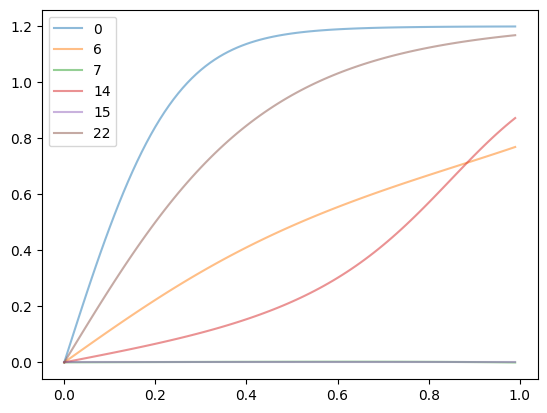

In [39]:
plots(df)

(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')
(34, 'Result too large')


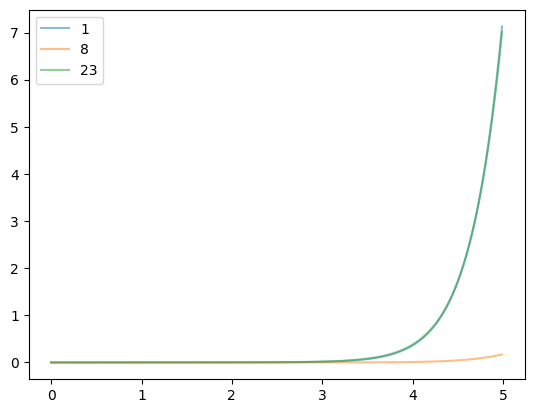

In [40]:
plots(df, max_x=5)

In [41]:
def plots_minimum(df: pd.DataFrame, n_points: int = 100):
    min_loss = df[df['loss'] != 0.0]['loss'].min()
    row: pd.DataFrame = df[df['loss'] == min_loss]
    max_x = row['max_x'].iloc[0]
    f = NewtonS([row[f'a{i}'].iloc[0] for i in range(1, 8, 2)], int(row['NS_n'].iloc[0]))
    x_es = [i/n_points for i in range(max_x * n_points)]
    y_es: list = [f(i/n_points) for i in range(max_x * n_points)]
    plt.plot(x_es, y_es)
    plt.show()
    return f

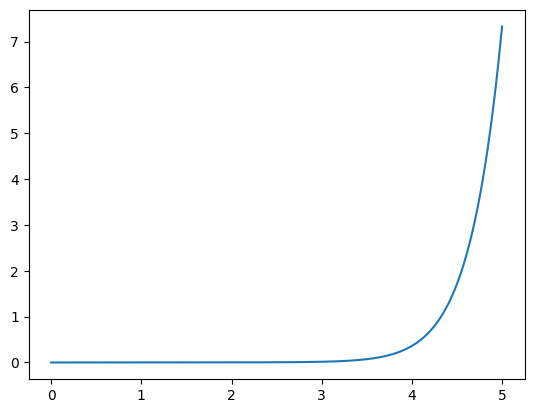

In [42]:
f = plots_minimum(df, 10000)